# **Deep Learning Klasifikasi Kepuasan Penumpang Pesawat**

Notebook ini digunakan untuk membangun dan mengevaluasi model **Deep Learning berbasis MLP (Multi-Layer Perceptron)** pada dua skenario:

1. **MLP Without Fuzzy**: menggunakan 5 fitur asli.
2. **MLP With Fuzzy**: menggunakan 5 fitur asli + `mamdani_score` + `sugeno_score`.

Catatan:
Pada Deep Learning digunakan `StandardScaler` untuk fitur numerik karena MLP menggunakan optimasi berbasis gradient. Ini berbeda dari Decision Tree, Random Forest, dan XGBoost yang tidak sensitif terhadap skala fitur.

## **0. Install dan Import Library**

In [23]:
!pip install -q tensorflow scikit-learn joblib

In [24]:
import os
import json
import random
import shutil

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## **1. Reproducibility**

Seed digunakan agar hasil training lebih stabil saat notebook dijalankan ulang. Hasil Deep Learning tetap bisa sedikit berbeda karena proses training neural network memiliki beberapa sumber variasi.

In [25]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## **2. Load Dataset**

In [26]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train_hybrid = pd.read_csv("train_hybrid.csv")
test_hybrid = pd.read_csv("test_hybrid.csv")

print("Train shape        :", train.shape)
print("Test shape         :", test.shape)
print("Train hybrid shape :", train_hybrid.shape)
print("Test hybrid shape  :", test_hybrid.shape)

display(train.head())
display(train_hybrid.head())

Train shape        : (103904, 6)
Test shape         : (25976, 6)
Train hybrid shape : (103904, 8)
Test hybrid shape  : (25976, 8)


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction
0,Personal Travel,Eco Plus,3,3,5,neutral or dissatisfied
1,Business travel,Business,3,3,1,neutral or dissatisfied
2,Business travel,Business,2,5,5,satisfied
3,Business travel,Business,2,2,2,neutral or dissatisfied
4,Business travel,Business,3,5,3,satisfied


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction,mamdani_score,sugeno_score
0,Personal Travel,Eco Plus,3,3,5,neutral or dissatisfied,51.052953,60.714286
1,Business travel,Business,3,3,1,neutral or dissatisfied,51.052953,58.333333
2,Business travel,Business,2,5,5,satisfied,83.666667,75.000000
3,Business travel,Business,2,2,2,neutral or dissatisfied,48.947047,45.000000
4,Business travel,Business,3,5,3,satisfied,83.666667,75.000000


Train shape        : (103904, 6)
Test shape         : (25976, 6)
Train hybrid shape : (103904, 8)
Test hybrid shape  : (25976, 8)


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction
0,Personal Travel,Eco Plus,3,3,5,neutral or dissatisfied
1,Business travel,Business,3,3,1,neutral or dissatisfied
2,Business travel,Business,2,5,5,satisfied
3,Business travel,Business,2,2,2,neutral or dissatisfied
4,Business travel,Business,3,5,3,satisfied


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction,mamdani_score,sugeno_score
0,Personal Travel,Eco Plus,3,3,5,neutral or dissatisfied,51.052953,60.714286
1,Business travel,Business,3,3,1,neutral or dissatisfied,51.052953,58.333333
2,Business travel,Business,2,5,5,satisfied,83.666667,75.000000
3,Business travel,Business,2,2,2,neutral or dissatisfied,48.947047,45.000000
4,Business travel,Business,3,5,3,satisfied,83.666667,75.000000


## **3. Validasi Dataset**

In [27]:
print("Missing value train:")
display(train.isnull().sum())

print("Missing value test:")
display(test.isnull().sum())

print("Missing value train_hybrid:")
display(train_hybrid.isnull().sum())

print("Missing value test_hybrid:")
display(test_hybrid.isnull().sum())

print("Distribusi target train:")
display(train["satisfaction"].value_counts(normalize=True).mul(100).round(2))

print("Distribusi target test:")
display(test["satisfaction"].value_counts(normalize=True).mul(100).round(2))

Missing value train:


,0
Type of Travel,0
Class,0
Inflight wifi service,0
Online boarding,0
Inflight entertainment,0
satisfaction,0


Missing value test:


,0
Type of Travel,0
Class,0
Inflight wifi service,0
Online boarding,0
Inflight entertainment,0
satisfaction,0


Missing value train_hybrid:


...

,0
Type of Travel,0
Class,0
Inflight wifi service,0
Online boarding,0
Inflight entertainment,0
satisfaction,0
mamdani_score,0
sugeno_score,0


Distribusi target train:


,proportion
satisfaction,
neutral or dissatisfied,56.67
satisfied,43.33


Distribusi target test:


,proportion
satisfaction,
neutral or dissatisfied,56.1
satisfied,43.9


## **4. Konfigurasi Fitur dan Target**

In [28]:
TARGET = "satisfaction"

FEATURES_ORIGINAL = [
    "Type of Travel",
    "Class",
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment"
]

FEATURES_HYBRID = [
    "Type of Travel",
    "Class",
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment",
    "mamdani_score",
    "sugeno_score"
]

CATEGORICAL_FEATURES = ["Type of Travel", "Class"]

NUMERICAL_ORIGINAL = [
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment"
]

NUMERICAL_HYBRID = [
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment",
    "mamdani_score",
    "sugeno_score"
]

print("Original features:", FEATURES_ORIGINAL)
print("Hybrid features  :", FEATURES_HYBRID)

Original features: ['Type of Travel', 'Class', 'Inflight wifi service', 'Online boarding', 'Inflight entertainment']
Hybrid features  : ['Type of Travel', 'Class', 'Inflight wifi service', 'Online boarding', 'Inflight entertainment', 'mamdani_score', 'sugeno_score']
Original features: ['Type of Travel', 'Class', 'Inflight wifi service', 'Online boarding', 'Inflight entertainment']
Hybrid features  : ['Type of Travel', 'Class', 'Inflight wifi service', 'Online boarding', 'Inflight entertainment', 'mamdani_score', 'sugeno_score']


## **5. Encode Label Target**

Mapping target:

- `neutral or dissatisfied` = 0
- `satisfied` = 1

In [29]:
label_encoder = LabelEncoder()

y_train_original = label_encoder.fit_transform(train[TARGET])
y_test_original = label_encoder.transform(test[TARGET])

y_train_hybrid = label_encoder.transform(train_hybrid[TARGET])
y_test_hybrid = label_encoder.transform(test_hybrid[TARGET])

print("Label mapping:")
for label, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label} -> {encoded}")

Label mapping:
neutral or dissatisfied -> 0
satisfied -> 1
Label mapping:
neutral or dissatisfied -> 0
satisfied -> 1


## **6. Siapkan Data Original dan Hybrid**

In [30]:
X_train_original = train[FEATURES_ORIGINAL]
X_test_original = test[FEATURES_ORIGINAL]

X_train_hybrid = train_hybrid[FEATURES_HYBRID]
X_test_hybrid = test_hybrid[FEATURES_HYBRID]

print("X_train_original:", X_train_original.shape)
print("X_test_original :", X_test_original.shape)
print("X_train_hybrid  :", X_train_hybrid.shape)
print("X_test_hybrid   :", X_test_hybrid.shape)

X_train_original: (103904, 5)
X_test_original : (25976, 5)
X_train_hybrid  : (103904, 7)
X_test_hybrid   : (25976, 7)
X_train_original: (103904, 5)
X_test_original : (25976, 5)
X_train_hybrid  : (103904, 7)
X_test_hybrid   : (25976, 7)


## **7. Fungsi Preprocessing**

Preprocessing:

- Fitur kategorikal = `OneHotEncoder`
- Fitur numerik = `StandardScaler`

Scaling digunakan pada MLP karena neural network dilatih dengan optimasi berbasis gradient. Untuk skenario hybrid, scaling juga menghindari ketimpangan skala antara fitur layanan 0-5 dan fuzzy score 0-100.

In [31]:
def build_preprocessor(numerical_features):
    # Membangun preprocessing untuk input MLP.
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ("num", StandardScaler(), numerical_features)
        ]
    )


def to_dense_array(matrix):
    # Mengubah sparse matrix menjadi dense array jika diperlukan.
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return matrix

## **8. Fungsi Membuat Model MLP**

In [32]:
def build_mlp_model(input_dim):
    # Membangun model MLP untuk klasifikasi biner.
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.25),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.20),

        Dense(16, activation="relu"),
        Dropout(0.10),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

## **9. Fungsi Training dan Evaluasi MLP**

In [33]:
def run_mlp_experiment(
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    numerical_features
):
    # Melakukan preprocessing, training MLP, prediksi, dan evaluasi.
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    preprocessor = build_preprocessor(numerical_features)

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    X_train_processed = to_dense_array(X_train_processed)
    X_test_processed = to_dense_array(X_test_processed)

    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train_processed,
        y_train,
        test_size=0.2,
        random_state=SEED,
        stratify=y_train
    )

    input_dim = X_train_processed.shape[1]
    model = build_mlp_model(input_dim)

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=0.00001
    )

    history = model.fit(
        X_train_sub,
        y_train_sub,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=256,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    y_pred_proba = model.predict(X_test_processed).ravel()
    y_pred = (y_pred_proba >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("===== Evaluation Result =====")
    print("Accuracy :", round(accuracy, 6))
    print("Precision:", round(precision, 6))
    print("Recall   :", round(recall, 6))
    print("F1 Score :", round(f1, 6))

    print("Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    return model, preprocessor, history, y_pred, y_pred_proba, metrics

## **10. Training MLP Without Fuzzy**

In [34]:
(
    mlp_original_model,
    mlp_original_preprocessor,
    history_original,
    y_pred_mlp_original,
    y_pred_proba_mlp_original,
    metrics_mlp_original
) = run_mlp_experiment(
    model_name="MLP Without Fuzzy",
    X_train=X_train_original,
    y_train=y_train_original,
    X_test=X_test_original,
    y_test=y_test_original,
    numerical_features=NUMERICAL_ORIGINAL
)

MLP Without Fuzzy
Epoch 1/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8559 - loss: 0.3347 - val_accuracy: 0.9036 - val_loss: 0.2427 - learning_rate: 0.0010
Epoch 2/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9028 - loss: 0.2347 - val_accuracy: 0.9219 - val_loss: 0.1914 - learning_rate: 0.0010
Epoch 3/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9093 - loss: 0.2192 - val_accuracy: 0.9231 - val_loss: 0.1859 - learning_rate: 0.0010
Epoch 4/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9104 - loss: 0.2141 - val_accuracy: 0.9230 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 5/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9131 - loss: 0.2102 - val_accuracy: 0.9260 - val_loss: 0.1819 - learning_rate: 0.0010
Epoch 6/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9138 - loss: 0.2064 - val_accuracy: 0.9259 - val_loss: 0.1814 - learning_rate: 0.0010
Epoch 7/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accu

## **11. Training MLP With Fuzzy**

In [35]:
(
    mlp_hybrid_model,
    mlp_hybrid_preprocessor,
    history_hybrid,
    y_pred_mlp_hybrid,
    y_pred_proba_mlp_hybrid,
    metrics_mlp_hybrid
) = run_mlp_experiment(
    model_name="MLP With Fuzzy",
    X_train=X_train_hybrid,
    y_train=y_train_hybrid,
    X_test=X_test_hybrid,
    y_test=y_test_hybrid,
    numerical_features=NUMERICAL_HYBRID
)

MLP With Fuzzy
Epoch 1/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8729 - loss: 0.3051 - val_accuracy: 0.8932 - val_loss: 0.2361 - learning_rate: 0.0010
Epoch 2/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9021 - loss: 0.2355 - val_accuracy: 0.9177 - val_loss: 0.1954 - learning_rate: 0.0010
Epoch 3/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9074 - loss: 0.2203 - val_accuracy: 0.9198 - val_loss: 0.1887 - learning_rate: 0.0010
Epoch 4/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9088 - loss: 0.2151 - val_accuracy: 0.9216 - val_loss: 0.1866 - learning_rate: 0.0010
Epoch 5/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9110 - loss: 0.2105 - val_accuracy: 0.9217 - val_loss: 0.1845 - learning_rate: 0.0010
Epoch 6/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9129 - loss: 0.2062 - val_accuracy: 0.9230 - val_loss: 0.1835 - learning_rate: 0.0010
Epoch 7/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.

## **12. Visualisasi Training Curve**

In [36]:
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

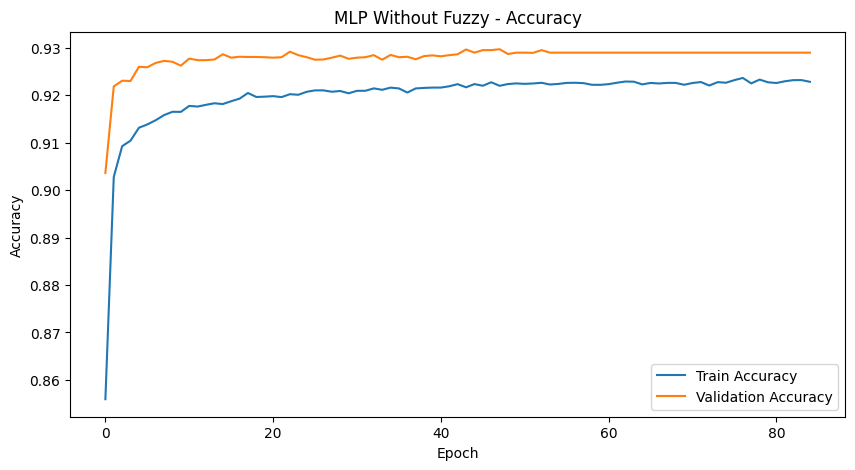

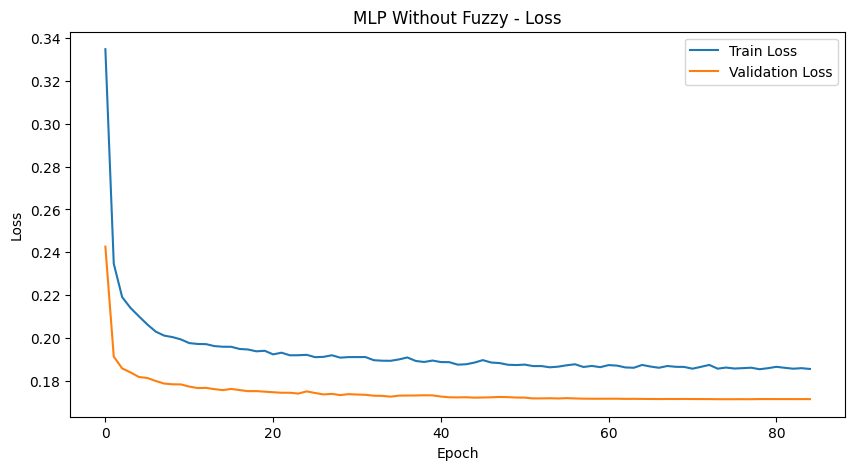

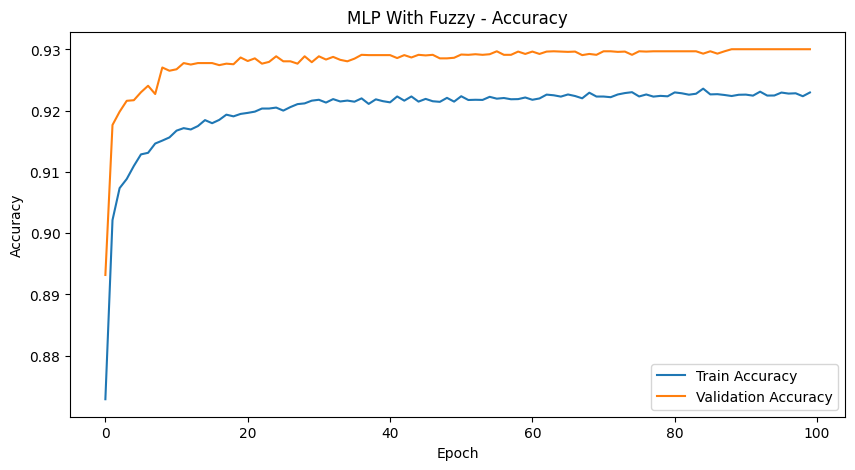

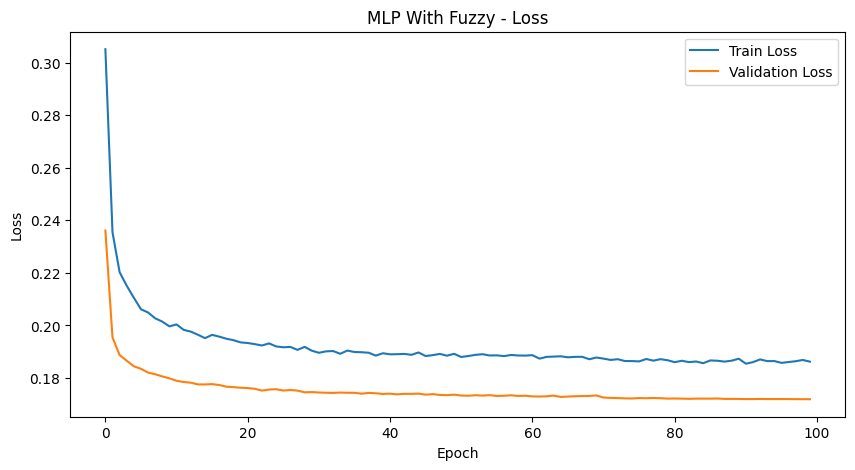

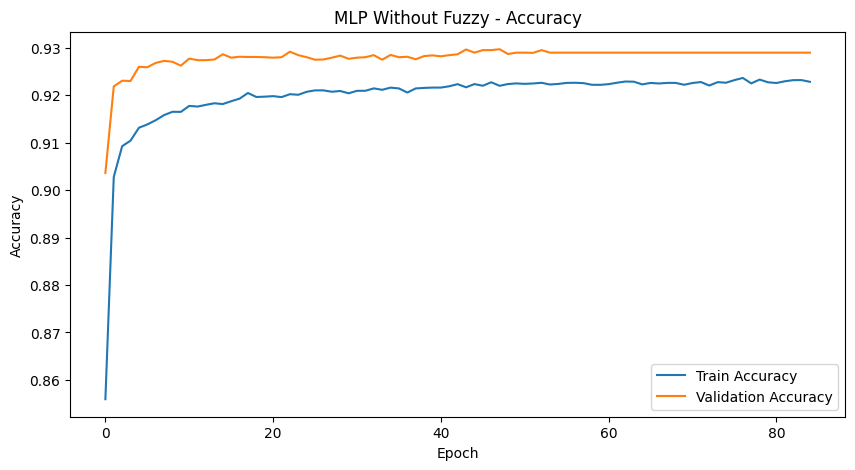

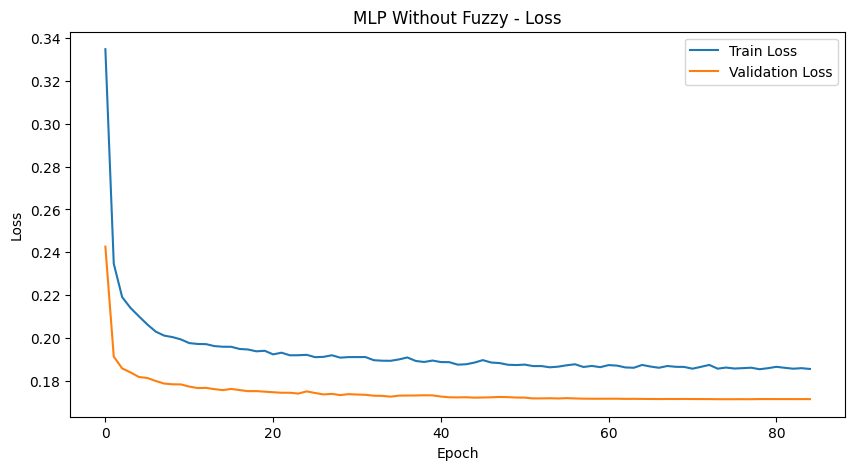

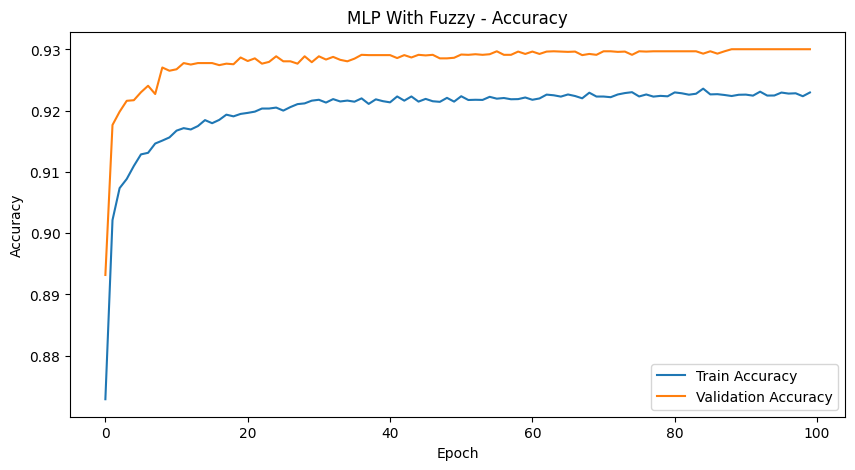

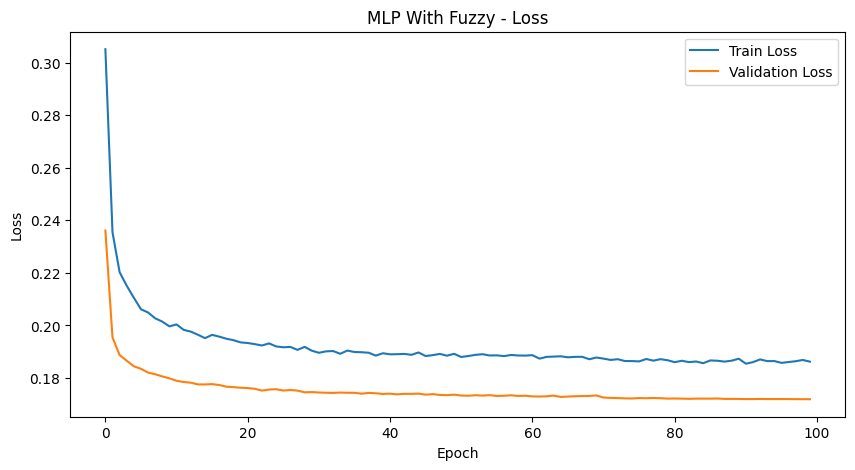

In [37]:
plot_training_history(history_original, "MLP Without Fuzzy")
plot_training_history(history_hybrid, "MLP With Fuzzy")

## **13. Perbandingan MLP Without Fuzzy vs With Fuzzy**

In [38]:
comparison_mlp = pd.DataFrame([
    metrics_mlp_original,
    metrics_mlp_hybrid
])

comparison_mlp = comparison_mlp[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
]

display(comparison_mlp)

,Model,Accuracy,Precision,Recall,F1 Score
0,MLP Without Fuzzy,0.925508,0.925337,0.903183,0.914126
1,MLP With Fuzzy,0.925547,0.928966,0.899149,0.913815


,Model,Accuracy,Precision,Recall,F1 Score
0,MLP Without Fuzzy,0.925508,0.925337,0.903183,0.914126
1,MLP With Fuzzy,0.925547,0.928966,0.899149,0.913815


In [39]:
comparison_mlp_delta = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Without Fuzzy": [
        metrics_mlp_original["Accuracy"],
        metrics_mlp_original["Precision"],
        metrics_mlp_original["Recall"],
        metrics_mlp_original["F1 Score"]
    ],
    "With Fuzzy": [
        metrics_mlp_hybrid["Accuracy"],
        metrics_mlp_hybrid["Precision"],
        metrics_mlp_hybrid["Recall"],
        metrics_mlp_hybrid["F1 Score"]
    ]
})

comparison_mlp_delta["Delta"] = (
    comparison_mlp_delta["With Fuzzy"] -
    comparison_mlp_delta["Without Fuzzy"]
)

display(comparison_mlp_delta)

,Metric,Without Fuzzy,With Fuzzy,Delta
0,Accuracy,0.925508,0.925547,0.000038
1,Precision,0.925337,0.928966,0.003629
2,Recall,0.903183,0.899149,-0.004034
3,F1 Score,0.914126,0.913815,-0.000311


,Metric,Without Fuzzy,With Fuzzy,Delta
0,Accuracy,0.925508,0.925547,0.000038
1,Precision,0.925337,0.928966,0.003629
2,Recall,0.903183,0.899149,-0.004034
3,F1 Score,0.914126,0.913815,-0.000311


## **14. Visualisasi Perbandingan MLP**

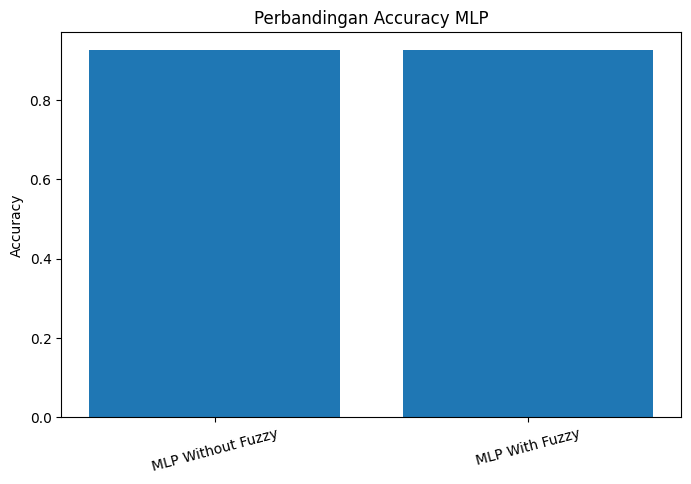

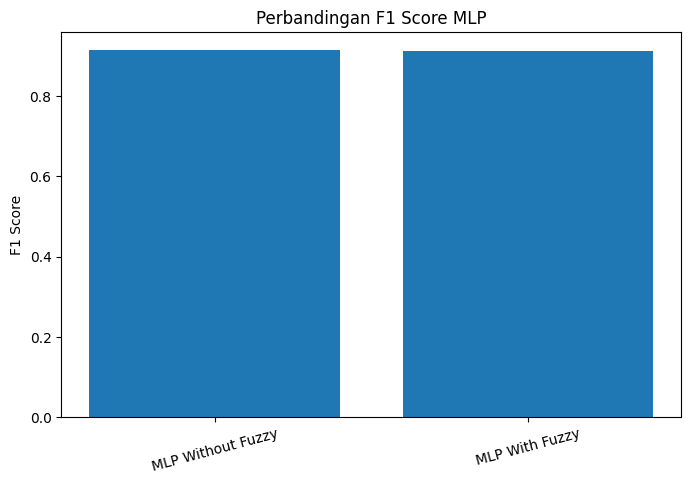

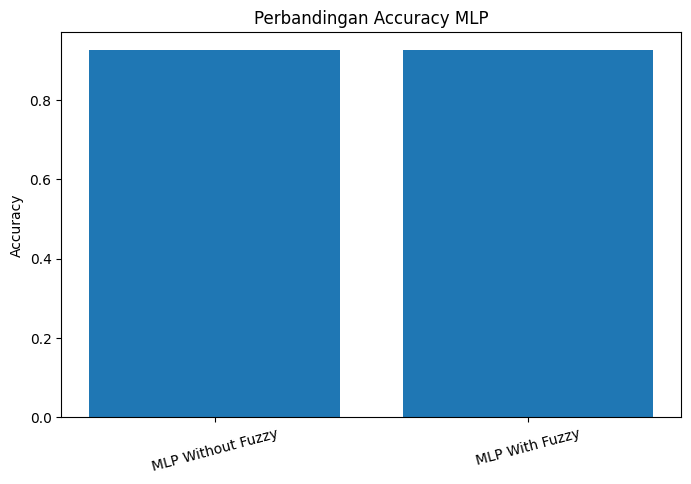

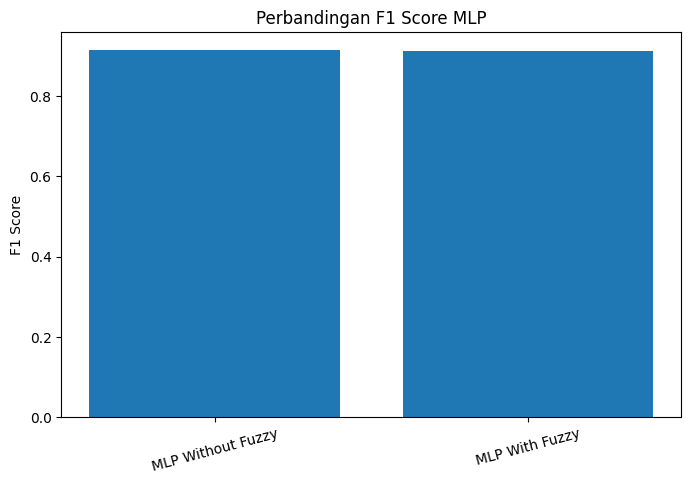

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_mlp["Model"], comparison_mlp["Accuracy"])
plt.title("Perbandingan Accuracy MLP")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_mlp["Model"], comparison_mlp["F1 Score"])
plt.title("Perbandingan F1 Score MLP")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.show()

## **15. Perbandingan dengan Model ML Sebelumnya**

In [41]:
previous_ml_results = pd.DataFrame([
    {"Model": "Logistic Regression Without Fuzzy", "Accuracy": 0.840699, "Precision": 0.815732, "Recall": 0.823029, "F1 Score": 0.819364},
    {"Model": "Logistic Regression With Fuzzy", "Accuracy": 0.844164, "Precision": 0.818923, "Recall": 0.828115, "F1 Score": 0.823494},
    {"Model": "Decision Tree Without Fuzzy", "Accuracy": 0.896789, "Precision": 0.917560, "Recall": 0.840393, "F1 Score": 0.877283},
    {"Model": "Decision Tree With Fuzzy", "Accuracy": 0.905528, "Precision": 0.891778, "Recall": 0.893186, "F1 Score": 0.892482},
    {"Model": "Random Forest Without Fuzzy", "Accuracy": 0.925316, "Precision": 0.929317, "Recall": 0.898185, "F1 Score": 0.913486},
    {"Model": "Random Forest With Fuzzy", "Accuracy": 0.925316, "Precision": 0.929317, "Recall": 0.898185, "F1 Score": 0.913486},
    {"Model": "XGBoost Without Fuzzy", "Accuracy": 0.921851, "Precision": 0.926705, "Recall": 0.892572, "F1 Score": 0.909318},
    {"Model": "XGBoost With Fuzzy", "Accuracy": 0.925200, "Precision": 0.929531, "Recall": 0.897659, "F1 Score": 0.913317},
])

comparison_final = pd.concat(
    [previous_ml_results, comparison_mlp],
    ignore_index=True
)

display(comparison_final.sort_values(by="F1 Score", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
8,MLP Without Fuzzy,0.925508,0.925337,0.903183,0.914126
9,MLP With Fuzzy,0.925547,0.928966,0.899149,0.913815
5,Random Forest With Fuzzy,0.925316,0.929317,0.898185,0.913486
4,Random Forest Without Fuzzy,0.925316,0.929317,0.898185,0.913486
7,XGBoost With Fuzzy,0.925200,0.929531,0.897659,0.913317
6,XGBoost Without Fuzzy,0.921851,0.926705,0.892572,0.909318
3,Decision Tree With Fuzzy,0.905528,0.891778,0.893186,0.892482
2,Decision Tree Without Fuzzy,0.896789,0.917560,0.840393,0.877283
1,Logistic Regression With Fuzzy,0.844164,0.818923,0.828115,0.823494
0,Logistic Regression Without Fuzzy,0.840699,0.815732,0.823029,0.819364


,Model,Accuracy,Precision,Recall,F1 Score
8,MLP Without Fuzzy,0.925508,0.925337,0.903183,0.914126
9,MLP With Fuzzy,0.925547,0.928966,0.899149,0.913815
5,Random Forest With Fuzzy,0.925316,0.929317,0.898185,0.913486
4,Random Forest Without Fuzzy,0.925316,0.929317,0.898185,0.913486
7,XGBoost With Fuzzy,0.925200,0.929531,0.897659,0.913317
6,XGBoost Without Fuzzy,0.921851,0.926705,0.892572,0.909318
3,Decision Tree With Fuzzy,0.905528,0.891778,0.893186,0.892482
2,Decision Tree Without Fuzzy,0.896789,0.917560,0.840393,0.877283
1,Logistic Regression With Fuzzy,0.844164,0.818923,0.828115,0.823494
0,Logistic Regression Without Fuzzy,0.840699,0.815732,0.823029,0.819364


## **16. Export Model Deep Learning**

In [42]:
EXPORT_DIR = "exported_dl_model"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Simpan model MLP
mlp_original_model.save(f"{EXPORT_DIR}/mlp_without_fuzzy.keras")
mlp_hybrid_model.save(f"{EXPORT_DIR}/mlp_with_fuzzy.keras")

# Simpan preprocessor
joblib.dump(mlp_original_preprocessor, f"{EXPORT_DIR}/mlp_without_fuzzy_preprocessor.pkl")
joblib.dump(mlp_hybrid_preprocessor, f"{EXPORT_DIR}/mlp_with_fuzzy_preprocessor.pkl")

# Simpan encoder dan daftar fitur
joblib.dump(label_encoder, f"{EXPORT_DIR}/label_encoder.pkl")
joblib.dump(FEATURES_ORIGINAL, f"{EXPORT_DIR}/features_original.pkl")
joblib.dump(FEATURES_HYBRID, f"{EXPORT_DIR}/features_hybrid.pkl")

# Simpan tabel metrik
comparison_mlp.to_csv(f"{EXPORT_DIR}/dl_metrics.csv", index=False)
comparison_mlp_delta.to_csv(f"{EXPORT_DIR}/dl_metrics_delta.csv", index=False)
comparison_final.to_csv(f"{EXPORT_DIR}/comparison_final_ml_dl.csv", index=False)

# Pilih model terbaik berdasarkan F1 Score
if metrics_mlp_hybrid["F1 Score"] >= metrics_mlp_original["F1 Score"]:
    best_model_name = "MLP With Fuzzy"
    best_model = mlp_hybrid_model
    best_preprocessor = mlp_hybrid_preprocessor
    best_features = FEATURES_HYBRID
    best_input_type = "hybrid"
else:
    best_model_name = "MLP Without Fuzzy"
    best_model = mlp_original_model
    best_preprocessor = mlp_original_preprocessor
    best_features = FEATURES_ORIGINAL
    best_input_type = "original"

best_model.save(f"{EXPORT_DIR}/best_mlp_model.keras")
joblib.dump(best_preprocessor, f"{EXPORT_DIR}/best_mlp_preprocessor.pkl")
joblib.dump(best_features, f"{EXPORT_DIR}/best_mlp_features.pkl")

model_info = {
    "best_model_name": best_model_name,
    "best_input_type": best_input_type,
    "threshold": 0.5,
    "target_mapping": {
        str(label): int(encoded)
        for label, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    },
    "metrics_mlp_without_fuzzy": metrics_mlp_original,
    "metrics_mlp_with_fuzzy": metrics_mlp_hybrid
}

with open(f"{EXPORT_DIR}/dl_model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model DL berhasil diekspor ke folder:", EXPORT_DIR)
print("Model terbaik:", best_model_name)
print("Daftar file:")
for filename in sorted(os.listdir(EXPORT_DIR)):
    print("-", filename)

Model DL berhasil diekspor ke folder: exported_dl_model
Model terbaik: MLP Without Fuzzy
Daftar file:
- best_mlp_features.pkl
- best_mlp_model.keras
- best_mlp_preprocessor.pkl
- comparison_final_ml_dl.csv
- dl_metrics.csv
- dl_metrics_delta.csv
- dl_model_info.json
- features_hybrid.pkl
- features_original.pkl
- label_encoder.pkl
- mlp_with_fuzzy.keras
- mlp_with_fuzzy_preprocessor.pkl
- mlp_without_fuzzy.keras
- mlp_without_fuzzy_preprocessor.pkl
Model DL berhasil diekspor ke folder: exported_dl_model
Model terbaik: MLP Without Fuzzy
Daftar file:
- best_mlp_features.pkl
- best_mlp_model.keras
- best_mlp_preprocessor.pkl
- comparison_final_ml_dl.csv
- dl_metrics.csv
- dl_metrics_delta.csv
- dl_model_info.json
- features_hybrid.pkl
- features_original.pkl
- label_encoder.pkl
- mlp_with_fuzzy.keras
- mlp_with_fuzzy_preprocessor.pkl
- mlp_without_fuzzy.keras
- mlp_without_fuzzy_preprocessor.pkl
